# 18. Консервативное восстановление space group для RRUFF

Исходный RRUFF JSON связывается с raw-выгрузкой IMA по точному или нормализованному
названию минерала. Fuzzy matching не используется. Старые FT-пулы сохраняются, новые
получают обязательный суффикс `with_rruff_sg`.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("Неверный путь.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from project_paths import *
ensure_project_directories()

print("Project root:", PROJECT_ROOT)

Project root: D:\Users\user\Desktop\DS_XRD_project


In [2]:
import subprocess

def run_script(script_name, *args):
    # Run one reproducible pipeline stage and stream its output.
    command = [sys.executable, str(PROJECT_ROOT / "src" / script_name), *map(str, args)]
    print("Running:", " ".join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

## Построение RRUFF → IMA mapping

In [3]:
run_script("enrich_rruff_spacegroups.py")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\enrich_rruff_spacegroups.py


## Новые RRUFF и combined FT-pools

In [4]:
run_script("build_rruff_sg_ft_pools.py")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\build_rruff_sg_ft_pools.py


## Покрытие новых SG-меток

{'rruff_json_records': 1362,
 'rruff_unique_ids': 1359,
 'mapping_rows': 1359,
 'rruff_unique_mineral_names': 806,
 'ima_records': 6228,
 'ima_rows_with_rruff_ids': 0,
 'normalized_name_collisions': 0,
 'match_method_counts': {'exact_name': 1295,
  'exact_plain_name': 48,
  'unmatched': 16},
 'status_counts': {'matched_ambiguous_spacegroup': 189,
  'matched_crystal_system_conflict': 3,
  'matched_no_spacegroup': 16,
  'matched_unresolved_symbol': 30,
  'unmatched_name': 16,
  'usable_after_crystal_system_filter': 128,
  'usable_unique_spacegroup': 977},
 'usable_json_records': 1107,
 'usable_unique_rruff_ids': 1105,
 'usable_fraction': 0.813098,
 'unresolved_symbols': {'P2_1/b': 12,
  'R-32/c': 9,
  'B2_1/d': 4,
  'Bbam': 4,
  'C2_1/d': 2,
  'F2/d': 1}}

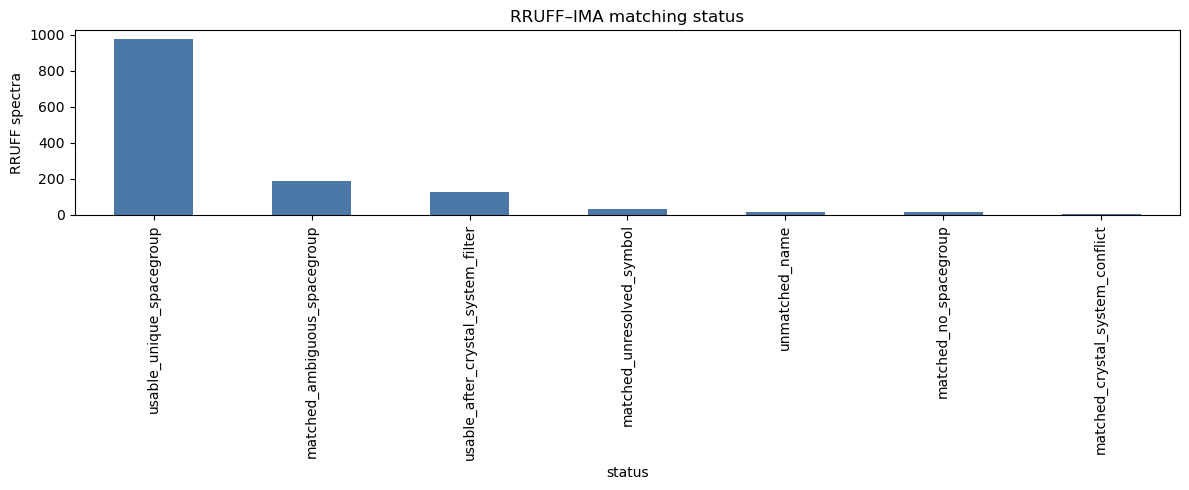

In [5]:
import json
import matplotlib.pyplot as plt
import pandas as pd

mapping = pd.read_csv(SOURCE_DIR / "rruff_spacegroup_mapping.csv")
summary = json.loads((OUTPUTS_DIR / "rruff_spacegroup_mapping_summary.json").read_text(encoding="utf-8"))
display(summary)
counts = mapping["status"].value_counts()
ax = counts.plot.bar(figsize=(12, 5), color="#4C78A8")
ax.set_title("RRUFF–IMA matching status")
ax.set_ylabel("RRUFF spectra")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "18_rruff_sg_mapping_status.png", dpi=160, bbox_inches="tight")
plt.show()

## Вывод

Ожидаемый результат — 1105 пригодных SG-меток из 1359 очищенных RRUFF-строк.